<a href="https://colab.research.google.com/github/quanvo06/chembl__eda.ipynb/blob/main/Project_1_(Mini)_EDA_ChEMBL_Data_Part_2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

TẢI conda and rdkit

In [1]:
%pip install rdkit-pypi

  Using cached rdkit_pypi-2022.9.5-cp37-cp37m-manylinux_2_17_x86_64.manylinux2014_x86_64.whl (29.2 MB)


In [4]:
import sys
print(sys.version)
print(sys.executable)

3.12.13 (main, Mar  4 2026, 09:23:07) [GCC 11.4.0]
/usr/bin/python3


In [3]:
from rdkit import Chem

from rdkit.Chem import Draw

mol = Chem.MolFromSmiles("c1ccccc1")

Draw.MolToImage(mol)

ModuleNotFoundError: No module named 'rdkit'

MỞ LẠI FILE

In [2]:
from google.colab import files

uploaded = files.upload()

Saving hoatchat_data_3_daxuly_dachuanhoa.csv to hoatchat_data_3_daxuly_dachuanhoa.csv


In [3]:
import pandas as pd

PD ĐỌC FILE

In [4]:
df = pd.read_csv('hoatchat_data_3_daxuly_dachuanhoa.csv')
df

,molecule_chembl_id,canonical_smiles,standard_value,class
0,CHEMBL133897,CCOc1nn(-c2cccc(OCc3ccccc3)c2)c(=O)o1,750.0,active
1,CHEMBL336398,O=C(N1CCCCC1)n1nc(-c2ccc(Cl)cc2)nc1SCC1CC1,100.0,active
2,CHEMBL131588,CN(C(=O)n1nc(-c2ccc(Cl)cc2)nc1SCC(F)(F)F)c1ccccc1,50000.0,inactive
3,CHEMBL130628,O=C(N1CCCCC1)n1nc(-c2ccc(Cl)cc2)nc1SCC(F)(F)F,300.0,active
4,CHEMBL130478,CSc1nc(-c2ccc(OC(F)(F)F)cc2)nn1C(=O)N(C)C,800.0,active
...,...,...,...,...
6893,CHEMBL6054495,COc1cc(N)c(I)cc1C(=O)NCC1CCN(CC2CCCCC2)CC1,5090.0,intermediate
6894,CHEMBL5755069,Nc1cc(O)c(C(=O)CCC2CCN(CC3CCCCC3)CC2)cc1Cl,411.0,active
6895,CHEMBL5791030,CCOc1cc(N)c(Cl)cc1C(=O)CCC1CCN(CC2CCCCC2)CC1,395.0,active
6896,CHEMBL5799857,Nc1cc(OCCF)c(C(=O)CCC2CCN(CC3CCCCC3)CC2)cc1Cl,625.0,active


LỌC LẠI SMILES (BỎ CÁC THÀNH PHẦN MUỐI,..)

In [5]:
df_no_smiles = df.drop(columns='canonical_smiles')

In [6]:
smiles = []

for i in df.canonical_smiles.tolist():
  cpd = str(i).split('.')
  cpd_longest = max(cpd, key = len)
  smiles.append(cpd_longest)

smiles = pd.Series(smiles, name = 'canonical_smiles')

In [7]:
df_clean_smiles = pd.concat([df_no_smiles,smiles], axis=1)
df_clean_smiles

,molecule_chembl_id,standard_value,class,canonical_smiles
0,CHEMBL133897,750.0,active,CCOc1nn(-c2cccc(OCc3ccccc3)c2)c(=O)o1
1,CHEMBL336398,100.0,active,O=C(N1CCCCC1)n1nc(-c2ccc(Cl)cc2)nc1SCC1CC1
2,CHEMBL131588,50000.0,inactive,CN(C(=O)n1nc(-c2ccc(Cl)cc2)nc1SCC(F)(F)F)c1ccccc1
3,CHEMBL130628,300.0,active,O=C(N1CCCCC1)n1nc(-c2ccc(Cl)cc2)nc1SCC(F)(F)F
4,CHEMBL130478,800.0,active,CSc1nc(-c2ccc(OC(F)(F)F)cc2)nn1C(=O)N(C)C
...,...,...,...,...
6893,CHEMBL6054495,5090.0,intermediate,COc1cc(N)c(I)cc1C(=O)NCC1CCN(CC2CCCCC2)CC1
6894,CHEMBL5755069,411.0,active,Nc1cc(O)c(C(=O)CCC2CCN(CC3CCCCC3)CC2)cc1Cl
6895,CHEMBL5791030,395.0,active,CCOc1cc(N)c(Cl)cc1C(=O)CCC1CCN(CC2CCCCC2)CC1
6896,CHEMBL5799857,625.0,active,Nc1cc(OCCF)c(C(=O)CCC2CCN(CC3CCCCC3)CC2)cc1Cl


CHUYỂN ĐỔI IC50 THÀNH PIC50

In [16]:
import numpy as np

def pIC50(input):
    pIC50 = []

    for i in input['standard_value_norm']:
        molar = i*(10**-9) # Converts nM to M
        pIC50.append(-np.log10(molar))

    input['pIC50'] = pIC50
    x = input.drop('standard_value_norm', axis=1)

    return x

In [19]:
df_clean_smiles.describe()

,standard_value
count,6.898000e+03
mean,9.923881e+04
std,8.720039e+05
min,0.000000e+00
25%,1.600000e+02
50%,2.420000e+03
75%,1.626500e+04
max,4.960000e+07


In [20]:
-np.log10( (10**-9)* 100000000 )

np.float64(1.0)

In [21]:
-np.log10( (10**-9)* 10000000000 )

np.float64(-1.0)

CHUẨN HOÁ IC50

In [22]:
def norm_value(input):
    norm = []

    for i in input['standard_value']:
        if i > 100000000:
          i = 100000000
        norm.append(i)

    input['standard_value_norm'] = norm
    x = input.drop('standard_value', axis=1)

    return x

In [24]:
df_norm = norm_value(df_clean_smiles)
df_norm


,molecule_chembl_id,class,canonical_smiles,standard_value_norm
0,CHEMBL133897,active,CCOc1nn(-c2cccc(OCc3ccccc3)c2)c(=O)o1,750.0
1,CHEMBL336398,active,O=C(N1CCCCC1)n1nc(-c2ccc(Cl)cc2)nc1SCC1CC1,100.0
2,CHEMBL131588,inactive,CN(C(=O)n1nc(-c2ccc(Cl)cc2)nc1SCC(F)(F)F)c1ccccc1,50000.0
3,CHEMBL130628,active,O=C(N1CCCCC1)n1nc(-c2ccc(Cl)cc2)nc1SCC(F)(F)F,300.0
4,CHEMBL130478,active,CSc1nc(-c2ccc(OC(F)(F)F)cc2)nn1C(=O)N(C)C,800.0
...,...,...,...,...
6893,CHEMBL6054495,intermediate,COc1cc(N)c(I)cc1C(=O)NCC1CCN(CC2CCCCC2)CC1,5090.0
6894,CHEMBL5755069,active,Nc1cc(O)c(C(=O)CCC2CCN(CC3CCCCC3)CC2)cc1Cl,411.0
6895,CHEMBL5791030,active,CCOc1cc(N)c(Cl)cc1C(=O)CCC1CCN(CC2CCCCC2)CC1,395.0
6896,CHEMBL5799857,active,Nc1cc(OCCF)c(C(=O)CCC2CCN(CC3CCCCC3)CC2)cc1Cl,625.0


KIỂM TRA DF NORM

In [25]:
df_norm.standard_value_norm.describe()

,standard_value_norm
count,6.898000e+03
mean,9.923881e+04
std,8.720039e+05
min,0.000000e+00
25%,1.600000e+02
50%,2.420000e+03
75%,1.626500e+04
max,4.960000e+07


In [26]:
df_final = pIC50(df_norm)
df_final

/tmp/ipykernel_23505/4018684485.py:8: RuntimeWarning: divide by zero encountered in log10
  pIC50.append(-np.log10(molar))


,molecule_chembl_id,class,canonical_smiles,pIC50
0,CHEMBL133897,active,CCOc1nn(-c2cccc(OCc3ccccc3)c2)c(=O)o1,6.124939
1,CHEMBL336398,active,O=C(N1CCCCC1)n1nc(-c2ccc(Cl)cc2)nc1SCC1CC1,7.000000
2,CHEMBL131588,inactive,CN(C(=O)n1nc(-c2ccc(Cl)cc2)nc1SCC(F)(F)F)c1ccccc1,4.301030
3,CHEMBL130628,active,O=C(N1CCCCC1)n1nc(-c2ccc(Cl)cc2)nc1SCC(F)(F)F,6.522879
4,CHEMBL130478,active,CSc1nc(-c2ccc(OC(F)(F)F)cc2)nn1C(=O)N(C)C,6.096910
...,...,...,...,...
6893,CHEMBL6054495,intermediate,COc1cc(N)c(I)cc1C(=O)NCC1CCN(CC2CCCCC2)CC1,5.293282
6894,CHEMBL5755069,active,Nc1cc(O)c(C(=O)CCC2CCN(CC3CCCCC3)CC2)cc1Cl,6.386158
6895,CHEMBL5791030,active,CCOc1cc(N)c(Cl)cc1C(=O)CCC1CCN(CC2CCCCC2)CC1,6.403403
6896,CHEMBL5799857,active,Nc1cc(OCCF)c(C(=O)CCC2CCN(CC3CCCCC3)CC2)cc1Cl,6.204120


In [27]:
df_final.pIC50.describe()

,pIC50
count,6898.000000
mean,inf
std,NaN
min,1.304518
25%,4.788746
50%,5.616185
75%,6.795880
max,inf


LƯU PIC50

In [28]:
df_final.to_csv('hoatchat_data_3_daxuly_dachuanhoa_pIC50.csv')

LỌC INTERMEDIATE

In [29]:
df_2class = df_final[df_final['class'] != 'intermediate']
df_2class

,molecule_chembl_id,class,canonical_smiles,pIC50
0,CHEMBL133897,active,CCOc1nn(-c2cccc(OCc3ccccc3)c2)c(=O)o1,6.124939
1,CHEMBL336398,active,O=C(N1CCCCC1)n1nc(-c2ccc(Cl)cc2)nc1SCC1CC1,7.000000
2,CHEMBL131588,inactive,CN(C(=O)n1nc(-c2ccc(Cl)cc2)nc1SCC(F)(F)F)c1ccccc1,4.301030
3,CHEMBL130628,active,O=C(N1CCCCC1)n1nc(-c2ccc(Cl)cc2)nc1SCC(F)(F)F,6.522879
4,CHEMBL130478,active,CSc1nc(-c2ccc(OC(F)(F)F)cc2)nn1C(=O)N(C)C,6.096910
...,...,...,...,...
6890,CHEMBL6040839,active,COc1cc(N)c(I)cc1C(=O)CCC1CCN(CC2CCCCC2)CC1,6.517126
6894,CHEMBL5755069,active,Nc1cc(O)c(C(=O)CCC2CCN(CC3CCCCC3)CC2)cc1Cl,6.386158
6895,CHEMBL5791030,active,CCOc1cc(N)c(Cl)cc1C(=O)CCC1CCN(CC2CCCCC2)CC1,6.403403
6896,CHEMBL5799857,active,Nc1cc(OCCF)c(C(=O)CCC2CCN(CC3CCCCC3)CC2)cc1Cl,6.204120


LƯU

In [30]:
df_final.to_csv('hoatchat_data_3_daxuly_dachuanhoa_pIC50_locinter.csv')

VẼ BIỂU ĐỒ

In [31]:
import seaborn as sns
sns.set(style='ticks')
import matplotlib.pyplot as plt

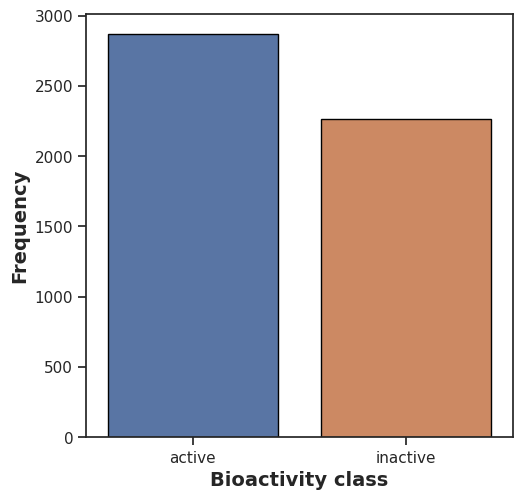

In [33]:
plt.figure(figsize=(5.5, 5.5))

sns.countplot(x='class', data=df_2class, edgecolor='black', hue='class')

plt.xlabel('Bioactivity class', fontsize=14, fontweight='bold')
plt.ylabel('Frequency', fontsize=14, fontweight='bold')

plt.savefig('plot_bioactivity_class.pdf')